In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("SmartCart.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handel Missing Values

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


### 2. Feature Engineering

In [6]:
# Year_Birth ====> Age
df["Age"] = 2026-df["Year_Birth"]


In [7]:
# Customer Joining Date

df['Dt_Customer'] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
refrence_date  = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (refrence_date - df['Dt_Customer']).dt.days

In [8]:
df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [9]:
# Spending
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [10]:
# Children
df["Total_Child"] =  df["Kidhome"] + df["Teenhome"]

In [11]:
#Education
df["Education"] =  df["Education"].replace(
    {
        "Basic" : "UnderGraduate", 
        "2n Cycle" : "UnderGraduate",

        "Graduation" : "Graduation",

        "Master" : "PostGraduation", 
        "PhD" : "PostGraduation"
    }
)

df["Education"].value_counts()

Education
Graduation        1127
PostGraduation     856
UnderGraduate      257
Name: count, dtype: int64

In [12]:
# Marital_Status

df["Living_status"] = df["Marital_Status"].replace(
    {
        "Married": "Partner",
        "Together": "Partner",

        "Single": "Alone",
        "Divorced": "Alone",
        "Widow": "Alone",
        "Absurd": "Alone",
        "YOLO": "Alone"
    }
)

df["Living_status"].value_counts()

Living_status
Partner    1444
Alone       796
Name: count, dtype: int64

In [13]:
# Drop Un-necessary Columns

cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts","MntGoldProds"]

clean_cols = cols + spending

df_cleaned = df.drop(columns = clean_cols)

In [14]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Child,Living_status
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduation,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


### 3. Outlier

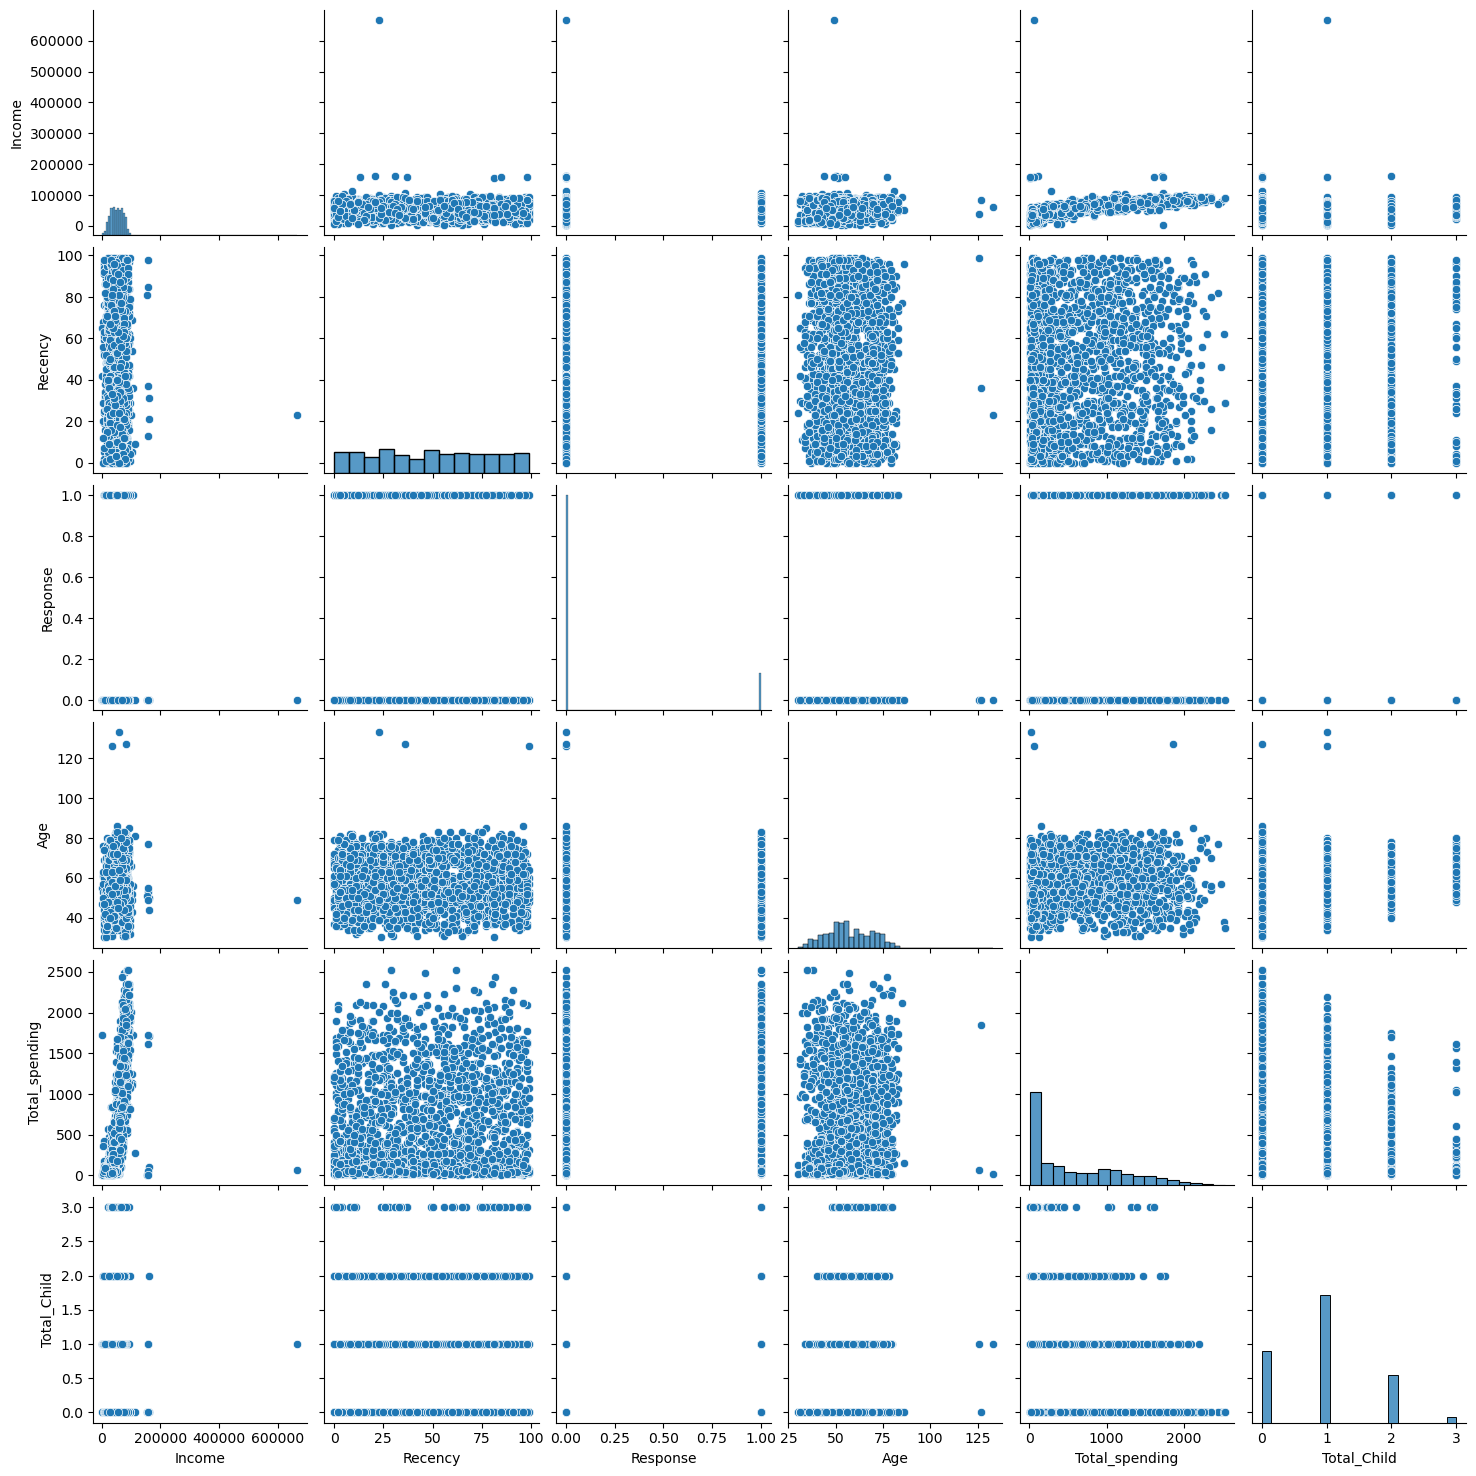

In [15]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_Child"]
sns.pairplot(df_cleaned[cols])

In [16]:
print("data size with outliers:", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned ["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned ["Income"] < 600_000)]
print("datasize without outliers:", len(df_cleaned))

data size with outliers: 2240
datasize without outliers: 2236


## 4. HeatMap

In [17]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

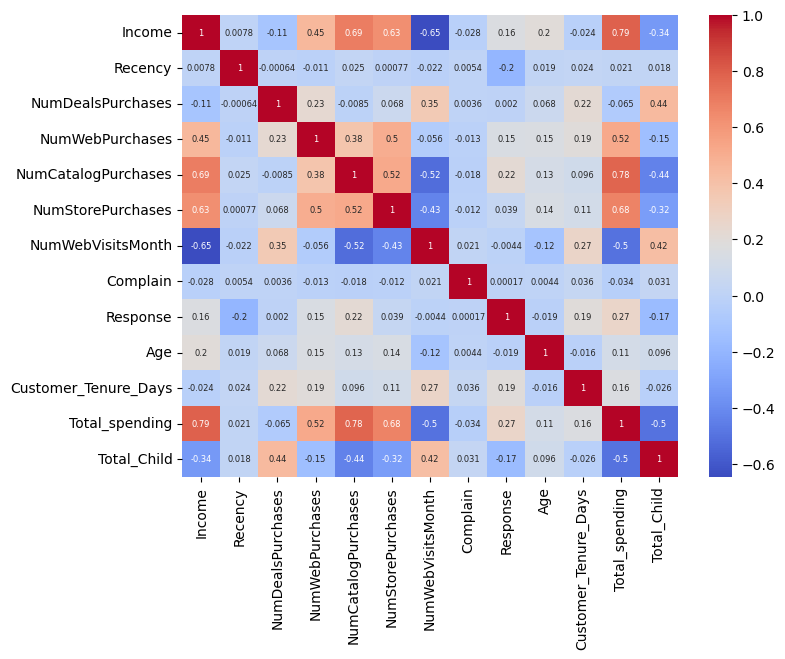

In [18]:
plt.figure(figsize =(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws ={"size":6},
    cmap = "coolwarm"
)

### 5. Encoding

In [19]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_status"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [20]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [21]:
enc_df.head()

,Education_Graduation,Education_PostGraduation,Education_UnderGraduate,Living_status_Alone,Living_status_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [22]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis = 1)

In [23]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Child,Education_Graduation,Education_PostGraduation,Education_UnderGraduate,Living_status_Alone,Living_status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [24]:
df_encoded.shape
X = df_encoded

### 6. Scaling

In [25]:
scaler = StandardScaler()

X_scaled= scaler.fit_transform(X)

### 7. Visulaization

In [26]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

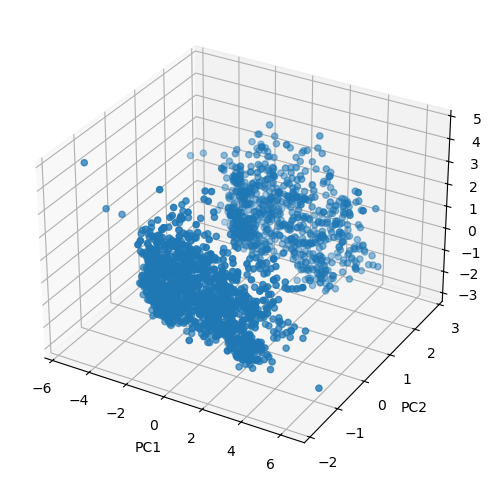

In [27]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(

    X_pca[:, 0],

    X_pca[:, 1],

    X_pca[:, 2]

)

ax.set_xlabel("PC1")

ax.set_ylabel("PC2")

ax.set_zlabel("PC3")

plt.show()

### 8. Analyze K Value 
1. Elbow Method 

In [28]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [29]:
knee = KneeLocator(range(1,11),wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

In [30]:
print("Best Optimal Value :", optimal_k)

Best Optimal Value : 4


Text(0, 0.5, 'WCSS')

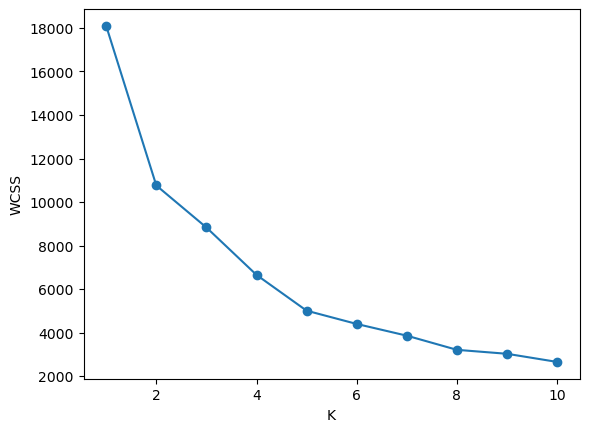

In [31]:
#plot 

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 8.2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

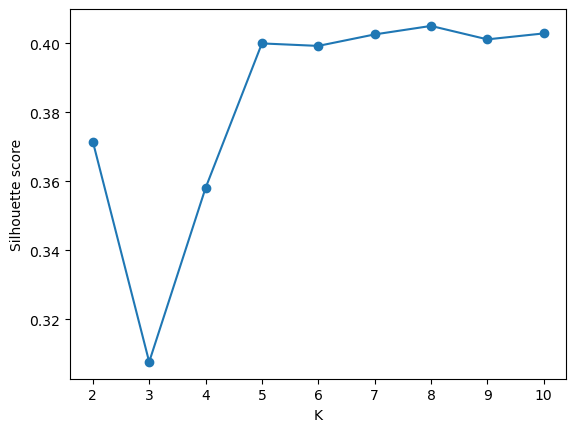

In [32]:
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)


## Plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

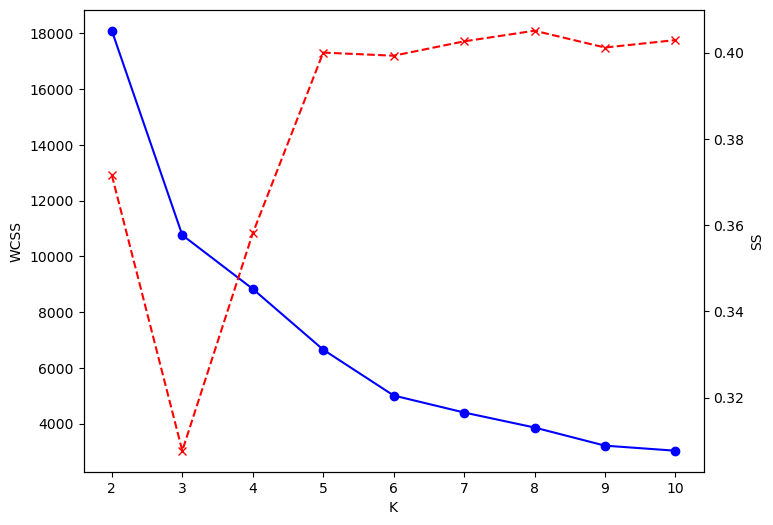

In [33]:
# combined plot KMeans -  Silhouette_score

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

### Clustering

In [34]:
# K_means

kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

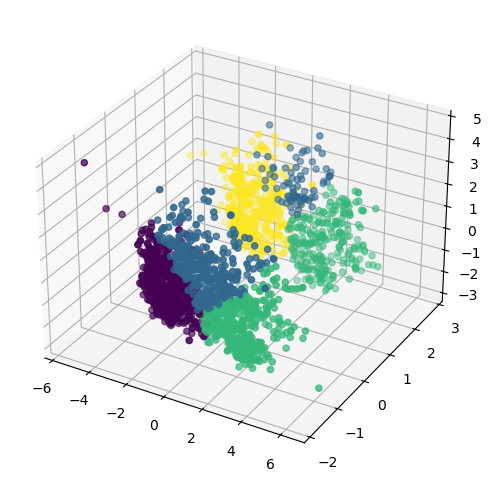

In [35]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [41]:
# Algomerative Clustering

agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

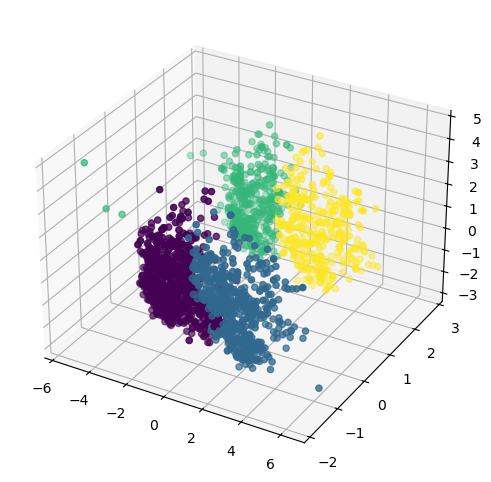

In [42]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

### 10. Characterization of Clusters 

In [43]:
X["cluster"] = labels_agg

In [44]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Child,Education_Graduation,Education_PostGraduation,Education_UnderGraduate,Living_status_Alone,Living_status_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

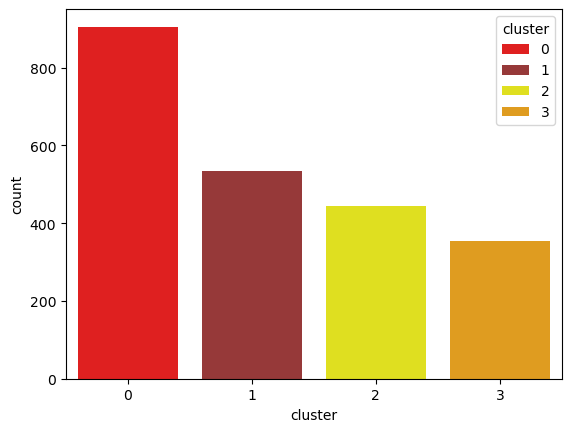

In [47]:
pal = ["red", "brown", "yellow", "orange"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

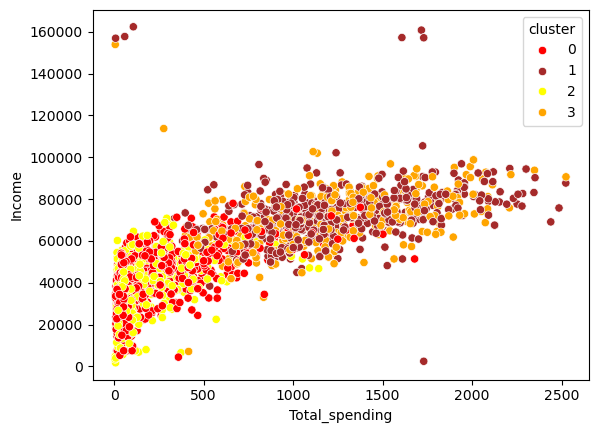

In [49]:
## Income Spending Patterns

sns.scatterplot(x = X["Total_spending"], y = X["Income"], hue = X["cluster"], palette = pal)

In [50]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         